In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# משתנים גלובליים
GLOBAL_USE_BATCHNORM = False
GLOBAL_LAMBD = 0
GLOBAL_PARAMETERS = {} 
GLOBAL_X_VAL = None    
GLOBAL_Y_VAL = None    

def load_and_preprocess_mnist():
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='liac-arff')
    X, y = mnist["data"], mnist["target"]
    X = X.T / 255.
    
    train_x_full = X[:, :60000]
    train_y_full = y[:60000].astype(int)
    test_x = X[:, 60000:]
    test_y = y[60000:].astype(int)

    def one_hot(Y):
        oh = np.zeros((10, Y.size))
        oh[Y, np.arange(Y.size)] = 1
        return oh

    test_y_oh = one_hot(test_y)

    m_total = train_x_full.shape[1]  # התיקון החשוב: אינדקס 1 במקום 15
    m_val = int(m_total * 0.2)
    
    np.random.seed(10)
    perm = np.random.permutation(m_total)
    
    val_x = train_x_full[:, perm[:m_val]]
    val_y = one_hot(train_y_full[perm[:m_val]])
    
    train_x = train_x_full[:, perm[m_val:]]
    train_y = one_hot(train_y_full[perm[m_val:]])
    
    print("Data loaded successfully!", flush=True)
    return train_x, train_y, val_x, val_y, test_x, test_y_oh

In [2]:
def initialize_parameters(layer_dims):
    parameters = {}
    L = len(layer_dims)
    for l in range(1, L):
        parameters[f"W{l}"] = np.random.randn(layer_dims[l], layer_dims[l-1]) * np.sqrt(2 / layer_dims[l-1])
        parameters[f"b{l}"] = np.zeros((layer_dims[l], 1))
    return parameters

def linear_forward(A, W, b):
    Z = (W @ A) + b
    linear_cache = { "A": A, "W": W, "b": b}
    return Z, linear_cache

def softmax(Z):
    shifted_Z = Z - np.max(Z, axis=0, keepdims=True)
    exp_Z = np.exp(shifted_Z)
    sum_exp_Z = np.sum(exp_Z, axis=0, keepdims=True)
    A = exp_Z / sum_exp_Z
    activation_cache = {"Z": Z}
    return A, activation_cache

def relu(Z):
    A = np.maximum(0, Z)
    activation_cache = {"Z": Z}
    return A, activation_cache

def apply_batchnorm(A):
    mean = np.mean(A, axis=1, keepdims=True)
    var = np.var(A, axis=1, keepdims=True)
    epsilon = 1e-8
    A_norm = (A - mean) / np.sqrt(var + epsilon)
    return A_norm

def linear_activation_forward(A_prev, W, b, activation):
    global GLOBAL_USE_BATCHNORM
    linear_z, linear_cache = linear_forward(A_prev, W, b)
    if activation == "softmax":
        A_raw, activation_cache = softmax(linear_z)
    elif activation == "relu":
        A_raw, activation_cache = relu(linear_z)
        
    if GLOBAL_USE_BATCHNORM and activation != "softmax":
        A = apply_batchnorm(A_raw)
        activation_cache["A_pre_norm"] = A_raw
    else:
        A = A_raw
    cache = (linear_cache, activation_cache)
    return A, cache

def l_model_forward(X, parameters, use_batchnorm):
    global GLOBAL_USE_BATCHNORM
    GLOBAL_USE_BATCHNORM = use_batchnorm 
    L = len(parameters) // 2
    curr_A = X
    all_cache = []
    for l in range(1, L):
        curr_A, curr_cache = linear_activation_forward(curr_A, parameters[f'W{l}'], parameters[f'b{l}'], "relu")
        all_cache.append(curr_cache)
    AL, curr_cache = linear_activation_forward(curr_A, parameters[f'W{L}'], parameters[f'b{L}'], "softmax")
    all_cache.append(curr_cache)
    return AL, all_cache

def compute_cost(AL, Y):
    global GLOBAL_LAMBD, GLOBAL_PARAMETERS
    m = Y.shape[1]
    cross_entropy_cost = -np.mean(np.sum(Y * np.log(AL + 1e-8), axis=0))
    l2_cost = 0
    if GLOBAL_LAMBD > 0 and len(GLOBAL_PARAMETERS) > 0:
        L = len(GLOBAL_PARAMETERS) // 2
        sum_weights_squared = 0
        for l in range(1, L + 1):
            sum_weights_squared += np.sum(np.square(GLOBAL_PARAMETERS[f"W{l}"]))
        l2_cost = (GLOBAL_LAMBD / (2 * m)) * sum_weights_squared
    return cross_entropy_cost + l2_cost

def linear_backward(dZ, cache):
    global GLOBAL_LAMBD
    A_prev = cache['A']
    W = cache['W']
    b = cache['b']
    m = A_prev.shape[1]
    dW = (1 / m) * np.dot(dZ, A_prev.T)
    if GLOBAL_LAMBD > 0:
        dW = dW + (GLOBAL_LAMBD / m) * W
    db = (1 / m) * np.sum(dZ, axis=1, keepdims=True)
    dA_prev = np.dot(W.T, dZ)
    return dA_prev, dW, db

def batchnorm_backward(dZ_norm, Z_original):
    m = dZ_norm.shape[1]
    epsilon = 1e-8
    mu = np.mean(Z_original, axis=1, keepdims=True)
    var = np.var(Z_original, axis=1, keepdims=True)
    std_inv = 1.0 / np.sqrt(var + epsilon)
    Z_norm = (Z_original - mu) * std_inv
    dZ = (1./m) * std_inv * (
        m * dZ_norm -
        np.sum(dZ_norm, axis=1, keepdims=True) -
        Z_norm * np.sum(dZ_norm * Z_norm, axis=1, keepdims=True)
    )
    return dZ

def relu_backward(dA, activation_cache):
    Z = activation_cache["Z"]
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    return dZ

def softmax_backward(dA, activation_cache):
    Z = activation_cache["Z"]
    AL, _ = softmax(Z)
    dZ = AL - dA
    return dZ

def linear_activation_backward(dA, cache, activation):
    global GLOBAL_USE_BATCHNORM
    linear_cache, activation_cache = cache
    if GLOBAL_USE_BATCHNORM and activation != "softmax":
        A_pre_norm = activation_cache['A_pre_norm']
        dA = batchnorm_backward(dA, A_pre_norm)
    if activation == "relu":
        dZ = relu_backward(dA, activation_cache)
    elif activation == "softmax":
        dZ = softmax_backward(dA, activation_cache)
    dA_prev, dW, db = linear_backward(dZ, linear_cache)
    return dA_prev, dW, db

def l_model_backward(AL, Y, caches):
    grads = {}
    L = len(caches)
    current_cache = caches[L-1]
    grads["dA" + str(L-1)], grads["dW" + str(L)], grads["db" + str(L)] = linear_activation_backward(Y, current_cache, "softmax")
    for l in reversed(range(L-1)):
        current_cache = caches[l]
        dA_prev_temp, dW_temp, db_temp = linear_activation_backward(grads["dA" + str(l+1)], current_cache, "relu")
        grads["dA" + str(l)] = dA_prev_temp
        grads["dW" + str(l + 1)] = dW_temp
        grads["db" + str(l + 1)] = db_temp
    return grads

def update_parameters(parameters, grads, learning_rate):
    L = len(parameters) // 2
    for l in range(L):
        layer_num = l + 1
        parameters["W" + str(layer_num)] = parameters["W" + str(layer_num)] - learning_rate * grads["dW" + str(layer_num)]
        parameters["b" + str(layer_num)] = parameters["b" + str(layer_num)] - learning_rate * grads["db" + str(layer_num)]
    return parameters

In [3]:
def l_layer_model(X, Y, layers_dims, learning_rate, num_iterations, batch_size):
    global GLOBAL_USE_BATCHNORM, GLOBAL_LAMBD, GLOBAL_PARAMETERS, GLOBAL_X_VAL, GLOBAL_Y_VAL
    np.random.seed(42)
    
    train_costs = []
    val_costs = []
    iterations_list = []
    
    parameters = initialize_parameters(layers_dims)
    GLOBAL_PARAMETERS = parameters 
    m = X.shape[1]
    best_val_cost    = np.inf
    no_improve_count = 0
    iteration        = 0
    
    for epoch in range(num_iterations):
        permutation  = np.random.permutation(m)
        X_shuffled   = X[:, permutation]
        Y_shuffled   = Y[:, permutation]
        
        for start in range(0, m, batch_size):
            end     = min(start + batch_size, m)
            X_batch = X_shuffled[:, start:end]
            Y_batch = Y_shuffled[:, start:end]
            
            AL, caches  = l_model_forward(X_batch, parameters, GLOBAL_USE_BATCHNORM)
            cost        = compute_cost(AL, Y_batch)
            grads       = l_model_backward(AL, Y_batch, caches)
            parameters  = update_parameters(parameters, grads, learning_rate)
            GLOBAL_PARAMETERS = parameters 
            iteration += 1
            
            if iteration % 100 == 0:
                train_AL, _ = l_model_forward(X, parameters, GLOBAL_USE_BATCHNORM)
                train_cost  = compute_cost(train_AL, Y)
                val_AL,  _ = l_model_forward(GLOBAL_X_VAL, parameters, GLOBAL_USE_BATCHNORM)
                val_cost   = compute_cost(val_AL, GLOBAL_Y_VAL)
                
                train_costs.append(train_cost)
                val_costs.append(val_cost)
                iterations_list.append(iteration)
                
                print(f"Iteration {iteration} | Train Cost: {train_cost:.6f} | Val Cost: {val_cost:.6f}")
                
                if val_cost >= best_val_cost - 1e-5:
                    no_improve_count += 1
                else:
                    no_improve_count  = 0
                    best_val_cost     = val_cost
                    
                if no_improve_count >= 1:
                    print(f"\n⛔ Early stopping at iteration {iteration} (epoch {epoch})")
                    return parameters, train_costs, val_costs, iterations_list
    return parameters, train_costs, val_costs, iterations_list

def predict(X, Y, parameters):
    global GLOBAL_USE_BATCHNORM
    AL, _ = l_model_forward(X, parameters, use_batchnorm=GLOBAL_USE_BATCHNORM)
    predictions = np.argmax(AL, axis=0)
    labels      = np.argmax(Y, axis=0)
    accuracy = np.mean(predictions == labels)
    return accuracy

def calculate_weights_norm(params):
    L = len(params) // 2
    total_norm = 0
    for l in range(1, L + 1):
        total_norm += np.sum(np.square(params[f"W{l}"]))
    return total_norm

def plot_costs(iters, train_costs, val_costs, title):
    plt.figure(figsize=(10,6))
    plt.plot(iters, train_costs, label="Train Cost", color="#1f77b4", linewidth=2)
    plt.plot(iters, val_costs, label="Validation Cost", color="#ff7f0e", linestyle="--", linewidth=2)
    plt.axvline(x=iters[-1], color='r', linestyle=':', alpha=0.6, label="Early Stopping")
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Training Iterations", fontsize=12)
    plt.ylabel("Cost", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

In [4]:
print("Loading data...", flush=True)
train_x, train_y, val_x, val_y, test_x, test_y_oh = load_and_preprocess_mnist()

GLOBAL_X_VAL = val_x
GLOBAL_Y_VAL = val_y

layers_dims = list((784, 20, 7, 5, 10))
learning_rate = 0.009
num_iterations = 3000
batch_size = 512

Loading data...
Data loaded successfully!



--- Starting Training: BASELINE ---
Iteration 100 | Train Cost: 1.935080 | Val Cost: 1.946253
Iteration 200 | Train Cost: 1.766616 | Val Cost: 1.776943
Iteration 300 | Train Cost: 1.673001 | Val Cost: 1.682963
Iteration 400 | Train Cost: 1.600903 | Val Cost: 1.610036
Iteration 500 | Train Cost: 1.534565 | Val Cost: 1.542008
Iteration 600 | Train Cost: 1.468644 | Val Cost: 1.474508
Iteration 700 | Train Cost: 1.402663 | Val Cost: 1.406917
Iteration 800 | Train Cost: 1.335415 | Val Cost: 1.337507
Iteration 900 | Train Cost: 1.269878 | Val Cost: 1.270271
Iteration 1000 | Train Cost: 1.208165 | Val Cost: 1.207444
Iteration 1100 | Train Cost: 1.149675 | Val Cost: 1.147760
Iteration 1200 | Train Cost: 1.096051 | Val Cost: 1.092950
Iteration 1300 | Train Cost: 1.044773 | Val Cost: 1.040482
Iteration 1400 | Train Cost: 0.994935 | Val Cost: 0.990863
Iteration 1500 | Train Cost: 0.947356 | Val Cost: 0.943446
Iteration 1600 | Train Cost: 0.904758 | Val Cost: 0.900840
Iteration 1700 | Train Cost:

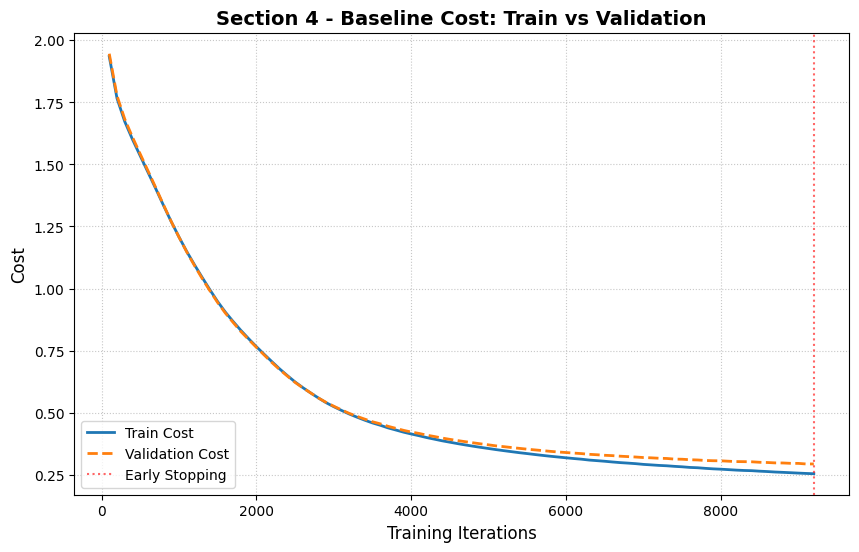


Train Accuracy: 93.02%
Validation Accuracy: 92.16%
Test Accuracy: 92.43%


In [5]:
# --- 1. Baseline ---
GLOBAL_USE_BATCHNORM = False
GLOBAL_LAMBD = 0
GLOBAL_PARAMETERS = {} 

print("\n" + "="*50)
print("--- Starting Training: BASELINE ---")
print("="*50)

parameters_base, t_costs_b, v_costs_b, iters_b = l_layer_model(train_x, train_y, layers_dims, learning_rate, num_iterations, batch_size)
plot_costs(iters_b, t_costs_b, v_costs_b, "Section 4 - Baseline Cost: Train vs Validation")

print(f"\nTrain Accuracy: {predict(train_x, train_y, parameters_base) * 100:.2f}%")
print(f"Validation Accuracy: {predict(val_x, val_y, parameters_base) * 100:.2f}%")
print(f"Test Accuracy: {predict(test_x, test_y_oh, parameters_base) * 100:.2f}%")


--- Starting Training: BATCHNORM ---
Iteration 100 | Train Cost: 1.628100 | Val Cost: 1.634674
Iteration 200 | Train Cost: 1.515106 | Val Cost: 1.524372
Iteration 300 | Train Cost: 1.425251 | Val Cost: 1.437194
Iteration 400 | Train Cost: 1.346896 | Val Cost: 1.358601
Iteration 500 | Train Cost: 1.278118 | Val Cost: 1.289602
Iteration 600 | Train Cost: 1.241405 | Val Cost: 1.251844
Iteration 700 | Train Cost: 1.176496 | Val Cost: 1.188455
Iteration 800 | Train Cost: 1.124622 | Val Cost: 1.138288
Iteration 900 | Train Cost: 1.076577 | Val Cost: 1.090761
Iteration 1000 | Train Cost: 1.034320 | Val Cost: 1.048578
Iteration 1100 | Train Cost: 0.997322 | Val Cost: 1.011350
Iteration 1200 | Train Cost: 0.963535 | Val Cost: 0.977925
Iteration 1300 | Train Cost: 0.932679 | Val Cost: 0.945926
Iteration 1400 | Train Cost: 0.904052 | Val Cost: 0.916570
Iteration 1500 | Train Cost: 0.875738 | Val Cost: 0.888506
Iteration 1600 | Train Cost: 0.848979 | Val Cost: 0.861674
Iteration 1700 | Train Cost

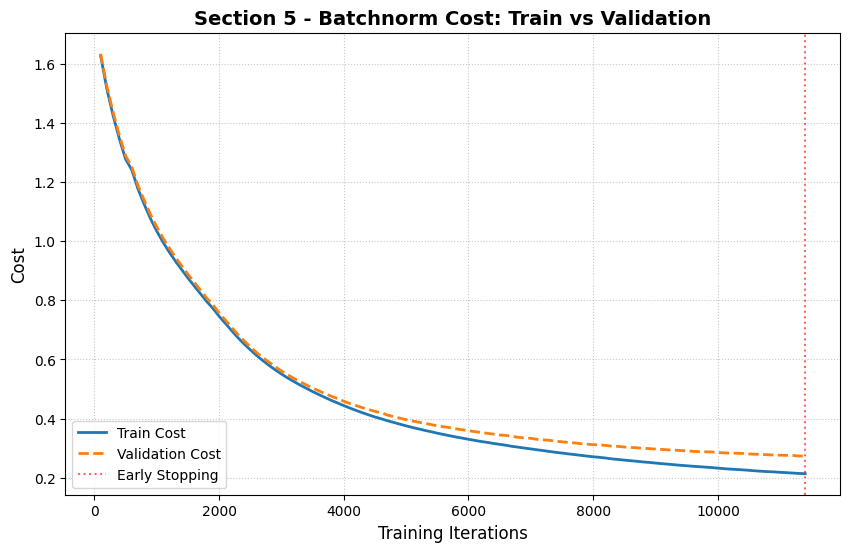


Train Accuracy: 95.04%
Validation Accuracy: 93.08%
Test Accuracy: 93.28%


In [6]:
# --- 2. Batchnorm ---
GLOBAL_USE_BATCHNORM = True
GLOBAL_LAMBD = 0
GLOBAL_PARAMETERS = {} 

print("\n" + "="*50)
print("--- Starting Training: BATCHNORM ---")
print("="*50)

parameters_bn, t_costs_bn, v_costs_bn, iters_bn = l_layer_model(train_x, train_y, layers_dims, learning_rate, num_iterations, batch_size)
plot_costs(iters_bn, t_costs_bn, v_costs_bn, "Section 5 - Batchnorm Cost: Train vs Validation")

print(f"\nTrain Accuracy: {predict(train_x, train_y, parameters_bn) * 100:.2f}%")
print(f"Validation Accuracy: {predict(val_x, val_y, parameters_bn) * 100:.2f}%")
print(f"Test Accuracy: {predict(test_x, test_y_oh, parameters_bn) * 100:.2f}%")



--- Starting Training: L2 REGULARIZATION ---
Iteration 100 | Train Cost: 1.935351 | Val Cost: 1.946808
Iteration 200 | Train Cost: 1.766979 | Val Cost: 1.777593
Iteration 300 | Train Cost: 1.673361 | Val Cost: 1.683600
Iteration 400 | Train Cost: 1.601311 | Val Cost: 1.610740
Iteration 500 | Train Cost: 1.535002 | Val Cost: 1.542745
Iteration 600 | Train Cost: 1.469145 | Val Cost: 1.475294
Iteration 700 | Train Cost: 1.403183 | Val Cost: 1.407670
Iteration 800 | Train Cost: 1.335990 | Val Cost: 1.338342
Iteration 900 | Train Cost: 1.270505 | Val Cost: 1.271123
Iteration 1000 | Train Cost: 1.208832 | Val Cost: 1.208368
Iteration 1100 | Train Cost: 1.150364 | Val Cost: 1.148689
Iteration 1200 | Train Cost: 1.096758 | Val Cost: 1.093973
Iteration 1300 | Train Cost: 1.045540 | Val Cost: 1.041512
Iteration 1400 | Train Cost: 0.995817 | Val Cost: 0.992055
Iteration 1500 | Train Cost: 0.948241 | Val Cost: 0.944617
Iteration 1600 | Train Cost: 0.905723 | Val Cost: 0.902113
Iteration 1700 | Tr

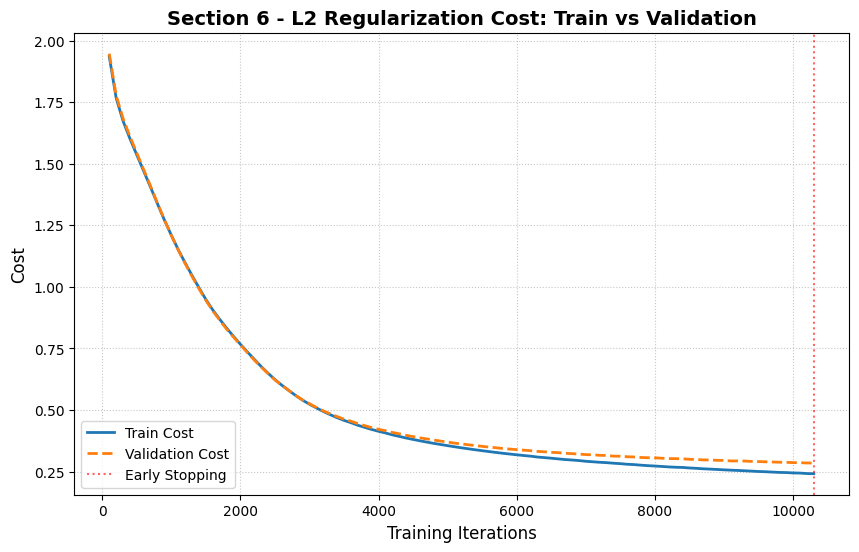


Train Accuracy: 93.43%
Validation Accuracy: 92.40%
Test Accuracy: 92.79%

--- Weights Comparison (Sum of Squared Weights) ---
Weights Norm without L2: 140.6412
Weights Norm with L2: 140.0314


In [7]:
# --- 3. L2 Regularization ---
GLOBAL_USE_BATCHNORM = False
GLOBAL_LAMBD = 0.1
GLOBAL_PARAMETERS = {} 

print("\n" + "="*50)
print("--- Starting Training: L2 REGULARIZATION ---")
print("="*50)

parameters_l2, t_costs_l2, v_costs_l2, iters_l2 = l_layer_model(train_x, train_y, layers_dims, learning_rate, num_iterations, batch_size)
plot_costs(iters_l2, t_costs_l2, v_costs_l2, "Section 6 - L2 Regularization Cost: Train vs Validation")

print(f"\nTrain Accuracy: {predict(train_x, train_y, parameters_l2) * 100:.2f}%")
print(f"Validation Accuracy: {predict(val_x, val_y, parameters_l2) * 100:.2f}%")
print(f"Test Accuracy: {predict(test_x, test_y_oh, parameters_l2) * 100:.2f}%")

print("\n" + "="*50)
print("--- Weights Comparison (Sum of Squared Weights) ---")
print("="*50)
print(f"Weights Norm without L2: {calculate_weights_norm(parameters_base):.4f}")
print(f"Weights Norm with L2: {calculate_weights_norm(parameters_l2):.4f}")
